# Documentation: Analysis and Visualization of APCEMM Data

This Jupyter Notebook provides a comprehensive analysis and visualization of data generated by the APCEMM (Aerosol and Particle Contrail Evolution Model). The notebook includes functions for reading and processing the data, as well as various plots to visualize the evolution of ice mass, particle optical depth, and particle radius distribution over time.

## Workflow

1. **Import Libraries and Setup Plotting Settings**:
    - Import necessary libraries such as `os`, `xarray`, `numpy`, and `matplotlib`.
    - Configure plotting settings for consistent visualization.

2. **Define Functions for Data Processing**:
    - `apce_data_struct`: A class to store the processed data.
    - `read_apcemm_data`: A function to read and process APCEMM data from a specified directory.
    - `removeLow`: A function to filter out low values from an array.

3. **Read and Process Data**:
    - Use the `read_apcemm_data` function to read data from multiple test runs and store the results in variables.

4. **Plotting**:
    - **Ice Mass Over Time**: Plot the ice mass as a function of time for each test run.
    - **Particle Optical Depth Over Time**: Visualize the evolution of particle optical depth for all test runs and selected runs.
    - **Particle Radius Distribution Over Time**: Plot the particle radius distribution for different time points and test runs.
    - **2D Contours**: Generate 2D contour plots for ice aerosol particle number, ice water content (IWC), and relative humidity with respect to ice (RHi) over time.

## How to Use

1. **Setup**:
    - Ensure that the necessary libraries are installed (`os`, `xarray`, `numpy`, `matplotlib`).
    - Place the APCEMM output files in the specified directories.

2. **Run the Notebook**:
    - Execute the cells sequentially to import libraries, define functions, read data, and generate plots.
    - Modify the directory paths in the `read_apcemm_data` function calls to point to your data files.

3. **Visualize Results**:
    - The notebook provides various plots to help understand the evolution of ice mass, particle optical depth, and particle radius distribution over time.
    - Use the generated plots to analyze the behavior of the APCEMM model under different test conditions.

In [1]:
#Import Libs and setup plotting settings
import os.path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

SMALL_SIZE = 6
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Pre-Processing Data

## Function Library

In [2]:
#Functions that will be used for postprocessing
class apce_data_struct:
    def __init__(self, t, ds_t, icemass, h2omass, numparts):
        self.t = t
        self.ds_t = ds_t
        self.icemass = icemass
        self.h2omass = h2omass
        self.numparts = numparts
    
def read_apcemm_data(directory):
    t_mins = []
    ds_t = []
    ice_mass = []
    total_h2o_mass = []
    num_particles = []

    for file in sorted(os.listdir(directory)):
        if(file.startswith('ts_aerosol') and file.endswith('.nc')):
            file_path = os.path.join(directory,file)
            ds = xr.open_dataset(file_path, engine = "netcdf4", decode_times = False)
            ds_t.append(ds)
            tokens = file_path.split('.')
            mins = int(tokens[-2][-2:])
            hrs = int(tokens[-2][-4:-2])
            t_mins.append(hrs*60 + mins)

            ice_mass.append(ds["Ice Mass"])
            num_particles.append(ds["Number Ice Particles"])
            dx = abs(ds["x"][-1] - ds["x"][0])/len(ds["x"])
            dy = abs(ds["y"][-1] - ds["y"][0])/len(ds["y"])
            
            h2o_mass = np.sum(ds["H2O"]) * 1e6 / 6.022e23 * 0.018 * dx*dy + ds["Ice Mass"]
            total_h2o_mass.append(h2o_mass.values)
    return apce_data_struct(t_mins, ds_t, ice_mass, total_h2o_mass, num_particles)

def removeLow(arr, cutoff = 1e-3):
    func = lambda x: (x > cutoff) * x
    vfunc = np.vectorize(func)
    return vfunc(arr)

## Read in the data

In [3]:
num_files = 20
t = []
ds_t = []
ice_mass = []
total_h2o_mass = []

for i in range(1,num_files+1):
    directory = '/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_2/outputs/training/test_2_run_'+str(i)
    apce_data = read_apcemm_data(directory)
    t.append(apce_data.t)
    ds_t.append(apce_data.ds_t)
    ice_mass.append(apce_data.icemass)
    total_h2o_mass.append(apce_data.h2omass)


## Remove any erroneous APCEMM spikes

In [4]:
# Assigning to individual variables if needed
t1, t2, t3, t4, t5, t6, t7, t8, t9, t10 = t[:10]
ds_t1, ds_t2, ds_t3, ds_t4, ds_t5, ds_t6, ds_t7, ds_t8, ds_t9, ds_t10 = ds_t[:10]
ice_mass1, ice_mass2, ice_mass3, ice_mass4, ice_mass5, ice_mass6, ice_mass7, ice_mass8, ice_mass9, ice_mass10 = ice_mass[:10]
total_h2o_mass1, total_h2o_mass2, total_h2o_mass3, total_h2o_mass4, total_h2o_mass5, total_h2o_mass6, total_h2o_mass7, total_h2o_mass8, total_h2o_mass9, total_h2o_mass10 = total_h2o_mass[:10]

# Plotting

## Plotting variables that are a function of time

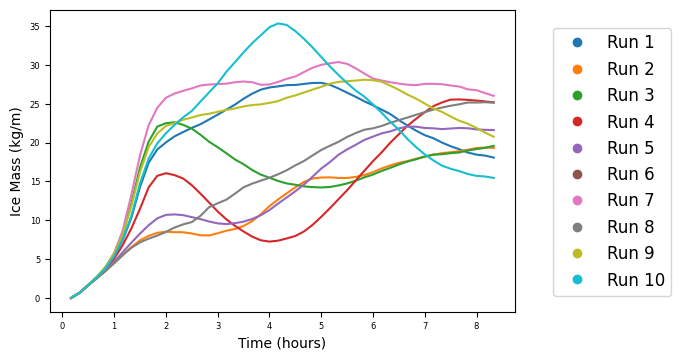

In [7]:
# Example of plotting variables that are a function of time
fig, axes = plt.subplots(dpi=100)
t_s = np.linspace(1,50,dtype=int)*10/60

# Define colors for different tests using the tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Plot ice_mass for each dataset
for i, (ice_mass, color) in enumerate(zip([ice_mass1, ice_mass2, ice_mass3, ice_mass4, ice_mass5, ice_mass6, ice_mass7, ice_mass8, ice_mass9, ice_mass10], colors), start=1):
    if len(ice_mass) >= 50:
        axes.plot(t_s, ice_mass[:50], label=f'Run {i}', color=color)

axes.set_xlabel("Time (hours)")
axes.set_ylabel("Ice Mass (kg/m)")

# Create custom legend for test numbers using dots
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', label=f'Run {i}') for i, color in enumerate(colors, start=1)]
fig.legend(handles=handles, bbox_to_anchor=(0.95, 0.5), loc='center left', fontsize='large', ncol=1)

plt.show()

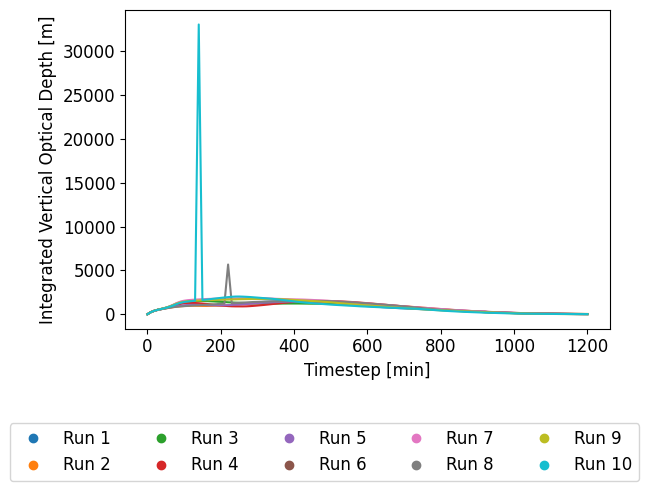

In [8]:
# Visualizing the evolution of the particle optical depth (intOD) over time for all runs
fig, ax = plt.subplots(dpi=100)

# Define colors for different tests using the tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Plot intOD for each dataset
for i, (ds_t, t, color) in enumerate(zip([ds_t1, ds_t2, ds_t3, ds_t4, ds_t5, ds_t6, ds_t7, ds_t8, ds_t9, ds_t10], 
                                         [t1, t2, t3, t4, t5, t6, t7, t8, t9, t10], colors), start=1):
    intOD_values = [ds['intOD'].values for ds in ds_t]
    ax.plot(t, intOD_values, label=f'Run {i}', color=color)

ax.set_xlabel("Timestep [min]", fontsize=12)
ax.set_ylabel("Integrated Vertical Optical Depth [m]", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=10)

# Create custom legend for test numbers using dots
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', label=f'Run {i}') for i, color in enumerate(colors, start=1)]
fig.legend(handles=handles, bbox_to_anchor=(0.5, -0.05), loc='upper center', fontsize='large', ncol=5)

plt.tight_layout()
plt.show()


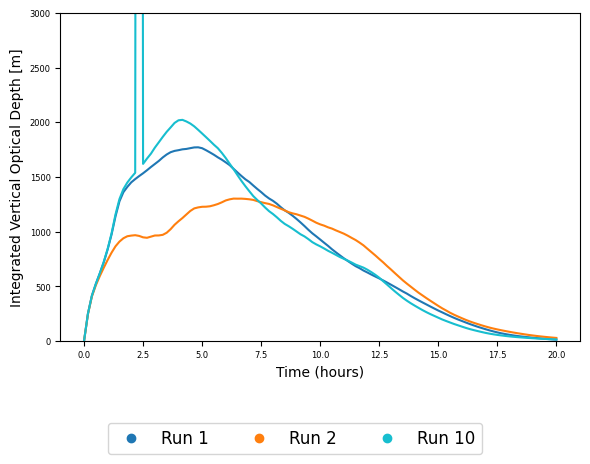

121


In [25]:
# Visualizing the evolution of the particle optical depth (intOD) over time for tests 1, 2, and 10
fig, ax = plt.subplots(dpi=100)

# Define colors for different tests using the tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, 10))[[0, 1, 9]]
ax.set_ylim(0,3000)
# Plot intOD for each dataset
for i, (ds_t, t, color) in enumerate(zip([ds_t1, ds_t2, ds_t10], [t1, t2, t10], colors), start=1):
    intOD_values = [ds['intOD'].values for ds in ds_t]
    label = f'Run {i}' if i != 3 else 'Run 10'
    ax.plot([time / 60 for time in t], intOD_values, label=label, color=color)

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Integrated Vertical Optical Depth [m]")

# Create custom legend for test numbers using dots
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', label=f'Run {i}' if i != 3 else 'Run 10') for i, color in enumerate(colors, start=1)]
fig.legend(handles=handles, bbox_to_anchor=(0.5, -0.05), loc='upper center', fontsize='large', ncol=3)

plt.tight_layout()
plt.show()
print(len(t1))

In [53]:
# # Open and display the contents of the NetCDF file
# file_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_2/inputs/training/APCEMM_met_10.nc'
# dataset = xr.open_dataset(file_path, engine="netcdf4")

# Calculate and print the difference between consecutive values of the 'relative_humidity_ice' variable for the last hour recorded in the file
# Extract and print the intOD values from ds_t10
intOD_values = [ds['intOD'].values[0] for ds in ds_t10]

# Calculate the difference between consecutive intOD values
vod_differences = np.diff(intOD_values)
print(vod_differences)

# Calculate and print the difference between consecutive values of the 'relative_humidity_ice' variable for the last hour recorded in the file
differences = np.diff(dataset['relative_humidity_ice'][95, :].values)

[ 2.5085289e+02  1.6320576e+02  1.0786066e+02  9.5596497e+01
  1.0391821e+02  1.2126575e+02  1.4198657e+02  1.7313385e+02
  1.3974646e+02  9.1050903e+01  6.0151001e+01  4.6994263e+01
  4.2003662e+01  3.1526025e+04 -3.1444422e+04  4.8556152e+01
  4.4712524e+01  5.5324463e+01  4.8772095e+01  4.9155029e+01
  4.6390137e+01  4.0170898e+01  4.1177856e+01  2.4057739e+01
  4.0749512e+00 -1.4608887e+01 -1.8986938e+01 -2.5833008e+01
 -3.2013428e+01 -3.3219360e+01 -3.3613403e+01 -3.3994629e+01
 -3.5028076e+01 -3.1902344e+01 -4.2292725e+01 -4.7407959e+01
 -5.2264038e+01 -5.0051636e+01 -5.4716064e+01 -5.2441895e+01
 -4.8416260e+01 -4.5811768e+01 -4.4277954e+01 -3.5136597e+01
 -3.2267700e+01 -3.6834961e+01 -3.3246582e+01 -2.6304565e+01
 -3.0234375e+01 -3.2584229e+01 -2.7798828e+01 -2.1044067e+01
 -2.3325562e+01 -2.5005981e+01 -2.5068542e+01 -1.9460144e+01
 -2.5156860e+01 -2.7345215e+01 -2.0583984e+01 -1.7810364e+01
 -1.9792236e+01 -2.1010254e+01 -1.8120728e+01 -1.9185913e+01
 -1.9524841e+01 -1.62139

##  Plot particle radius distribution

In [ ]:
# Visualizing the evolution of the particle radius distribution over time for tests 1-10
fig, axes = plt.subplots(1, 3, dpi=100, figsize=(15, 5))

# Define line styles for different times
line_styles = ['-', '--', '-.', ':']
time_labels = ['t = 0', 't = 5h', 't = 12h']
time_indices = [0, 30, 72]

# Define colors for different tests using the tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Plot for each test and each time point
for i, (ds_t, color) in enumerate(zip([ds_t1, ds_t2, ds_t3, ds_t4, ds_t5, ds_t6, ds_t7, ds_t8, ds_t9, ds_t10], colors), start=1):
    for ax, time_idx, time_label in zip(axes, time_indices, time_labels):
        ax.plot(ds_t[time_idx]['r'] * 1e6, removeLow(ds_t[time_idx]["Overall size distribution"], cutoff=1e9), linestyle=line_styles[0], color=color, label=f'Run {i}' if time_idx == 0 else "")

# Set labels and scales for each subplot
for ax, time_label in zip(axes, time_labels):
    ax.set_xlabel('Ice Crystal Radius (µm)', fontsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Number Ice Crystals', fontsize=14)
    ax.set_title(time_label, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)

# Create custom legend for test numbers using dots
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', label=f'Run {i}') for i, color in enumerate(colors, start=1)]
fig.legend(handles=handles, bbox_to_anchor=(0.5, -0.1), loc='upper center', fontsize='large', ncol=5)

plt.tight_layout()
plt.show()


In [ ]:
# Visualizing the evolution of the particle radius distribution over time for tests 1, 2, and 10
fig, axes = plt.subplots(1, 3, dpi=100, figsize=(15, 5))

# Define line styles for different times
line_styles = ['-', '--', '-.', ':']
time_labels = ['t = 0', 't = 5h', 't = 12h']
time_indices = [0, 30, 72]

# Define colors for different tests using the tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, 10))[[0, 1, 9]]

# Plot for each test and each time point
for i, (ds_t, color) in enumerate(zip([ds_t1, ds_t2, ds_t10], colors), start=1):
    for ax, time_idx, time_label in zip(axes, time_indices, time_labels):
        label = f'Run {i}' if time_idx == 0 else ""
        if i == 3:
            label = 'Run 10' if time_idx == 0 else ""
        ax.plot(ds_t[time_idx]['r'] * 1e6, removeLow(ds_t[time_idx]["Overall size distribution"], cutoff=1e9), linestyle=line_styles[0], color=color, label=label)

# Set labels and scales for each subplot
for ax, time_label in zip(axes, time_labels):
    ax.set_xlabel('Ice Crystal Radius (µm)', fontsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Number Ice Crystals', fontsize=14)
    ax.set_title(time_label, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)

# Create custom legend for test numbers using dots
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', label=f'Run {i}' if i != 3 else 'Run 10') for i, color in enumerate(colors, start=1)]
fig.legend(handles=handles, bbox_to_anchor=(0.5, -0.1), loc='upper center', fontsize='large', ncol=3)

plt.tight_layout()
plt.show()

# Print the largest ice crystal radius and the number of ice crystals associated with it for each line at t=12h
largest_radius1 = ds_t1[72]['r'].max() * 1e6
num_crystals1 = ds_t1[72]['Overall size distribution'].sel(r=ds_t1[72]['r'].max()).values
largest_radius2 = ds_t2[72]['r'].max() * 1e6
num_crystals2 = ds_t2[72]['Overall size distribution'].sel(r=ds_t2[72]['r'].max()).values
largest_radius10 = ds_t10[72]['r'].max() * 1e6
num_crystals10 = ds_t10[72]['Overall size distribution'].sel(r=ds_t10[72]['r'].max()).values

print(f'Largest ice crystal radius for test 1 at t=12h: {largest_radius1:.2f} µm, Number of ice crystals: {num_crystals1}')
print(f'Largest ice crystal radius for test 2 at t=12h: {largest_radius2:.2f} µm, Number of ice crystals: {num_crystals2}')
print(f'Largest ice crystal radius for test 10 at t=12h: {largest_radius10:.2f} µm, Number of ice crystals: {num_crystals10}')


## 2D contour plots

In [ ]:
#Looking at some 2D contours over time (e.g. Ice aerosol particle number)
fig, ((ax11, ax12, ax13)) = plt.subplots(nrows = 1, ncols = 3, dpi=200, figsize=[10, 2])
fig.suptitle("Ice aerosol particle number")

ds_t_1h = ds_t[6]
X_map1h, Y_map1h = np.meshgrid(ds_t_1h["x"], ds_t_1h["y"])
map1h = ax11.contourf(X_map1h, Y_map1h, ds_t_1h['Ice aerosol particle number'])
ax11.set_title('t = 1h')
plt.colorbar(map1h, ax = ax11,fraction=0.046, pad=0.1)


ds_t_3h = ds_t[18]
X_map3h, Y_map3h = np.meshgrid(ds_t_3h["x"], ds_t_3h["y"])
map3h=ax12.contourf(X_map3h, Y_map3h, ds_t_3h['Ice aerosol particle number'])
ax12.set_title('t = 3h')
plt.colorbar(map3h, ax = ax12,fraction=0.046, pad=0.1)


ds_t_5h = ds_t[84]
X_map5h, Y_map5h = np.meshgrid(ds_t_5h["x"], ds_t_5h["y"])
map5h=ax13.contourf(X_map5h, Y_map5h, ds_t_5h['Ice aerosol particle number'])
ax13.set_title('t = 5h')
plt.colorbar(map5h, ax = ax13,fraction=0.046, pad=0.1)


fig.tight_layout(pad=0.3)

plt.show()

In [ ]:
# Looking at a different 2D contour, IWC over time. Notice the contrast in ice particles vs ice mass distribution.
fig, ((ax11, ax12, ax13)) = plt.subplots(nrows=1, ncols=3, dpi=200, figsize=[10, 2])
fig.suptitle("Ice Water Content")

# Determine the common x and y limits
x_min = min(ds_t_1h["x"].min(), ds_t_3h["x"].min(), ds_t_5h["x"].min())
x_max = max(ds_t_1h["x"].max(), ds_t_3h["x"].max(), ds_t_5h["x"].max())
y_min = min(ds_t_1h["y"].min(), ds_t_3h["y"].min(), ds_t_5h["y"].min())
y_max = max(ds_t_1h["y"].max(), ds_t_3h["y"].max(), ds_t_5h["y"].max())

ds_t_1h = ds_t[6]
X_map1h, Y_map1h = np.meshgrid(ds_t_1h["x"], ds_t_1h["y"])
map1h = ax11.contourf(X_map1h, Y_map1h, ds_t_1h['IWC'], cmap='plasma_r')
ax11.set_title('t = 1h')
ax11.set_xlim(x_min, x_max)
ax11.set_ylim(y_min, y_max)
plt.colorbar(map1h, ax=ax11, fraction=0.046, pad=0.1)

ds_t_3h = ds_t[18]
X_map3h, Y_map3h = np.meshgrid(ds_t_3h["x"], ds_t_3h["y"])
map3h = ax12.contourf(X_map3h, Y_map3h, ds_t_3h['IWC'], cmap='plasma_r')
ax12.set_title('t = 3h')
ax12.set_xlim(x_min, x_max)
ax12.set_ylim(y_min, y_max)
plt.colorbar(map3h, ax=ax12, fraction=0.046, pad=0.1)

ds_t_5h = ds_t[86]
X_map5h, Y_map5h = np.meshgrid(ds_t_5h["x"], ds_t_5h["y"])
map5h = ax13.contourf(X_map5h, Y_map5h, ds_t_5h['IWC'], cmap='plasma_r')
ax13.set_title('t = 5h')
ax13.set_xlim(x_min, x_max)
ax13.set_ylim(y_min, y_max)
plt.colorbar(map5h, ax=ax13, fraction=0.046, pad=0.1)

fig.tight_layout(pad=0.3)
plt.show()
# Filter out the data points where x > 20000
for ax in [ax11, ax12, ax13]:
    ax.set_xlim(x_min, 20000)

plt.show()

In [ ]:
# To better understand this sharp cutoff at around Y = -600, we can also look at the RHi Plots, and see a discontinuity from supersaturation to subsaturation:
# Phenomena such as seeing spikes in supersaturation near the discontinuity due to instantaneous ice melting are also visible.
fig, ((ax11, ax12, ax13)) = plt.subplots(nrows=1, ncols=3, dpi=200, figsize=[10, 2])
fig.suptitle("RHi")

# Determine the common color scale limits
vmin = min(ds_t[1]['RHi'].min(), ds_t[18]['RHi'].min(), ds_t[30]['RHi'].min())
vmax = max(ds_t[1]['RHi'].max(), ds_t[18]['RHi'].max(), ds_t[30]['RHi'].max())

ds_t_1h = ds_t[1]
X_map1h, Y_map1h = np.meshgrid(ds_t_1h["x"], ds_t_1h["y"])
map1h = ax11.contourf(X_map1h, Y_map1h, ds_t_1h['RHi'], vmin=vmin, vmax=vmax, cmap='plasma_r')
ax11.set_title('t = 10 min')
ax11.set_xlim(x_min, x_max)
ax11.set_ylim(y_min, y_max)
plt.colorbar(map1h, ax=ax11, fraction=0.046, pad=0.1)

ds_t_3h = ds_t[80]
X_map3h, Y_map3h = np.meshgrid(ds_t_3h["x"], ds_t_3h["y"])
map3h = ax12.contourf(X_map3h, Y_map3h, ds_t_3h['RHi'], vmin=vmin, vmax=vmax, cmap='plasma_r')
ax12.set_title('t = 3h')
ax12.set_xlim(x_min, x_max)
ax12.set_ylim(y_min, y_max)
plt.colorbar(map3h, ax=ax12, fraction=0.046, pad=0.1)

ds_t_5h = ds_t[86]
X_map5h, Y_map5h = np.meshgrid(ds_t_5h["x"], ds_t_5h["y"])
map5h = ax13.contourf(X_map5h, Y_map5h, ds_t_5h['RHi'], vmin=vmin, vmax=vmax, cmap='plasma_r')
ax13.set_title('t = 5h')
ax13.set_xlim(x_min, x_max)
ax13.set_ylim(y_min, y_max)
plt.colorbar(map5h, ax=ax13, fraction=0.046, pad=0.1)

fig.tight_layout(pad=0.3)
plt.show()

# Filter out the data points where x > 20000
for ax in [ax11, ax12, ax13]:
    ax.set_xlim(x_min, 20000)

plt.show()